# PDF Parsing with Docling

## Raw Data Loading and Explore

In [4]:
from huggingface_hub import snapshot_download
from pathlib import Path
import json
import base64
from collections import Counter
from IPython.display import display, Image, HTML

In [ ]:
# Save data in PixelRAG/data/ relative to this notebook
local_data_dir = Path("data")
local_data_dir.mkdir(parents=True, exist_ok=True)

repo_dir = snapshot_download(
    repo_id="vectara/open_ragbench",
    repo_type="dataset",
    local_dir=str(local_data_dir),
    ignore_patterns=["*.gitattributes"]
)

print(f"Downloaded to: {repo_dir}")

Fetching ... files: 0it [00:00, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Fetching ... files: 1005it [00:36, 27.42it/s]

Downloaded to: /Users/hanhanwu/Documents/Github/Yokan/experiments_multimodal/PixelRAG/data


In [ ]:
base = Path("data/pdf/arxiv")

queries = json.loads((base / "queries.json").read_text())
qrels = json.loads((base / "qrels.json").read_text())
pdf_urls = json.loads((base / "pdf_urls.json").read_text())

print(f"Total queries: {len(queries)}")
print(f"Total qrels:   {len(qrels)}")
print(f"Total PDFs:    {len(pdf_urls)}")

source_counts = Counter(v["source"] for v in queries.values())
print("\nQuery sources:", source_counts)

Total queries: 3045
Total qrels:   3045
Total PDFs:    1000

Query sources: Counter({'text': 1914, 'text-image': 763, 'text-table-image': 220, 'text-table': 148})


#### Find the First Paper with both Image and Table

In [89]:
corpus_dir = Path("data/pdf/arxiv/corpus")
paper_files = sorted(corpus_dir.glob("*.json"))

min_images = 1
papers_with_both = []

for path in paper_files:
    doc = json.loads(path.read_text())
    img_count = sum(len(s.get("images", {})) for s in doc["sections"])
    table_count = sum(len(s.get("tables", {})) for s in doc["sections"])
    if img_count >= min_images and table_count > 0:
        papers_with_both.append((img_count, table_count, doc))

papers_with_both.sort(key=lambda x: (x[0], x[1]), reverse=True)

# Change this index to explore different papers
paper_index = 12
target_paper = papers_with_both[paper_index][2]

print(f"Index: {paper_index}")
print(f"Paper: {target_paper['title']}")
print(f"Images: {papers_with_both[paper_index][0]}")
print(f"Tables: {papers_with_both[paper_index][1]}")
print(f"Sections: {len(target_paper['sections'])}")

Index: 12
Paper: Unsolvable Problem Detection: Robust Understanding Evaluation for Large
  Multimodal Models
Images: 31
Tables: 18
Sections: 70


In [90]:
# Find first section with a table and render it as HTML
for section in target_paper["sections"]:
    if section.get("tables"):
        table_md = next(iter(section["tables"].values()))
        rows = [r.strip() for r in table_md.strip().splitlines() if r.strip() and "---" not in r]
        html = "<table border='1' style='border-collapse:collapse;font-size:12px'>"
        for i, row in enumerate(rows):
            tag = "th" if i == 0 else "td"
            cells = [c.strip() for c in row.strip("|").split("|")]
            html += "<tr>" + "".join(f"<{tag} style='padding:4px 8px'>{c}</{tag}>" for c in cells) + "</tr>"
        html += "</table>"
        display(HTML(f"<h4>Table from: {target_paper['title'][:60]}...</h4>" + html))
        break

,AAD,,,,IASD,,,,IVQD,,,
:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:
,Orig,Base,Opt,Inst,Orig,Base,Opt,Inst,Orig,Base,Opt,Inst
Open-source LMMs,,,,,,,,,,,,
LLaVA1.5-13b,74.4,0.7,38.8,37.1,70.9,5.7,46.0,52.0,68.8,0.0,39.3,31.7
LLaVA-NeXT-13B,76.7,17.8,18.2,38.3,73.2,27.0,29.6,55.9,71.3,33.1,37.9,54.2
LLaVA-NeXT-34B,84.3,50.5,29.9,55.1,80.2,48.9,22.6,61.8,80.9,55.3,50.6,72.5
LLaVA-OV-0.5B,67.0,22.2,18.2,0.1,64.4,17.8,11.5,3.8,59.6,9.6,7.9,3.1
LLaVA-OV-7B,86.0,4.5,29.4,25.9,82.5,5.5,37.0,27.1,84.8,2.5,50.6,47.8
Phi-3-Vision,80.4,0.1,27.4,38.8,77.0,0.1,46.5,49.0,79.5,0.0,56.2,61.0
Phi-3.5-Vision,80.2,1.8,22.2,27.7,77.1,0.3,23.9,33.2,77.2,0.3,52.5,55.9


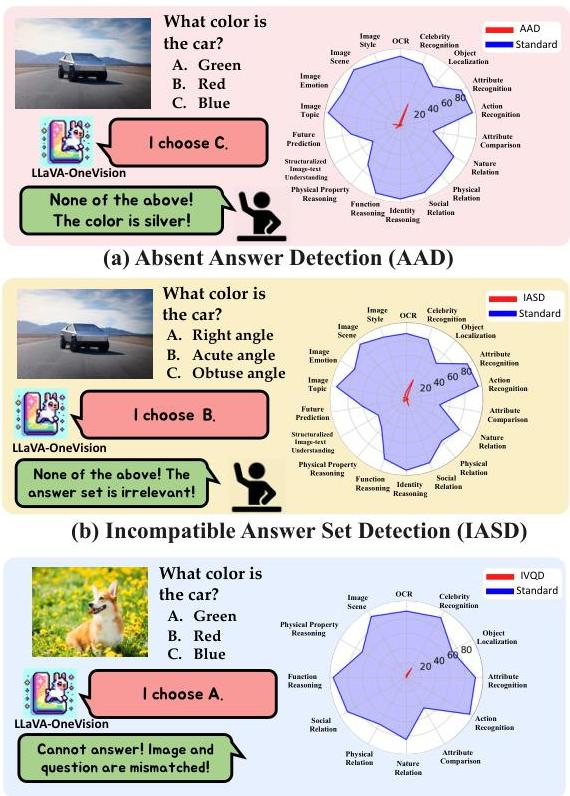

In [91]:
# Find first section with an image and display it
for section in target_paper["sections"]:
    if section.get("images"):
        img_b64 = next(iter(section["images"].values()))
        img_bytes = base64.b64decode(img_b64.split(",", 1)[1])
        display(Image(data=img_bytes, width=780))
        break

In [92]:
# Find queries linked to the selected paper
paper_id = target_paper.get("id")

if paper_id is None:
    raise KeyError(f"Could not find paper ID. Available keys: {list(target_paper.keys())}")

linked_query_ids = [
    qid for qid, rel in qrels.items()
    if rel["doc_id"] == paper_id
]

print(f"Queries linked to this paper: {len(linked_query_ids)}\n")
for qid in linked_query_ids[:5]:
    q = queries[qid]
    print(f"[{q['source']:20s}] [{q['type']:11s}]  {q['query'][:90]}")

Queries linked to this paper: 10

[text                ] [extractive ]  What does MM-UPD Bench stand for?
[text                ] [extractive ]  Is detailed justification required when refining problems during the curation process?
[text                ] [extractive ]  Is there a strong correlation between OC-Dual accuracy and Dual accuracy?
[text                ] [extractive ]  Does self-reflection allow models to evaluate their own answers?
[text                ] [extractive ]  What activity involves using ropes and harnesses on a cliff face?
